In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np



In [4]:
# to load the dataset 
df = pd.read_csv('../Data/nova_pay_combined.csv')
df.head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [ ]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [7]:
df.shape 

(11400, 26)

In [19]:
#percentage of missing values and to 2 decimal places 
round(df.isnull().mean() * 100, 2)

transaction_id               0.00
customer_id                  0.00
timestamp                    0.25
home_country                 0.00
source_currency              0.00
dest_currency                0.00
channel                      0.00
amount_src                   0.00
amount_usd                   2.68
fee                          2.59
exchange_rate_src_to_dest    0.00
device_id                    0.00
new_device                   0.00
ip_address                   2.68
ip_country                   2.64
location_mismatch            0.00
ip_risk_score                0.00
kyc_tier                     2.63
account_age_days             0.00
device_trust_score           2.59
chargeback_history_count     0.00
risk_score_internal          0.00
txn_velocity_1h              0.00
txn_velocity_24h             0.00
corridor_risk                0.00
is_fraud                     0.00
dtype: float64

In [20]:
# to check for duplicate 
df.duplicated().sum()
df[df.duplicated()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
10000,a5a4d5fc-f8df-4fa9-9ac6-36d3c4e3f1bb,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2024-10-21 18:24:40.468549+00:00,UK,GBP,CNY,mobile,79.41,99.26,1.78,...,0.127,standard,4,0.892,0,0.407,6,6,0.0,0
10001,88dd45c3-38b9-498f-a767-0fc20c598a89,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2023-08-29 10:22:29.468549+00:00,US,USD,GBP,mobile,-320.4,320.40,9999.99,...,1.200,standard,1018,-0.100,0,0.087,-1,0,0.0,0
10002,0de01bd2-638e-4c0d-800f-16c4528351de,d71c91b4-fee8-4104-9856-a5c6109a62e3,2025-08-25 11:42:34.468549+00:00,US,USD,USD,web,96.37,96.37,2.65,...,0.487,standard,298,0.336,0,0.166,0,0,0.0,0
10003,8f3264ec-53af-47ad-bf98-b870d9956173,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2025-09-04 08:07:31.468549+00:00,US,USD,GBP,ATM,53.16,53.16,1.66,...,0.405,enhanced,257,0.894,0,0.257,0,0,0.0,0
10004,a301be5c-bf14-411a-a201-3abf74de8a7e,402cccc9-28de-45b3-9af7-cc5302aa1f93,2025-01-27 15:05:01.468549+00:00,US,USD,USD,web,119.97,119.97,2.76,...,0.494,standard,263,0.522,0,0.223,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,a5c6391d-4763-4ed6-a5ef-80b744cf71b2,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-11-25 16:25:46.468549+00:00,US,USD,GBP,mobile,127.91,127.91,2.97,...,0.315,standard,1018,0.934,0,0.087,0,0,0.0,0
10196,35c133e7-7279-4d24-ac0e-967675f2c2a0,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2023-01-13 16:50:48.468549+00:00,US,USD,CNY,ATM,286.59,286.59,5.12,...,0.383,enhanced,257,0.894,0,0.257,0,0,0.0,0
10197,6263d697-0900-440c-99d7-b4be90e733b5,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2025-07-02 11:33:48.468549+00:00,US,USD,USD,mobile,230.09,230.09,4.01,...,0.244,enhanced,367,0.939,0,0.176,0,0,0.0,0
10198,883403f5-fd2f-4b39-824e-9710485a983e,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-01-01 02:40:14.468549+00:00,UK,GBP,PHP,mobile,-168.96,211.20,9999.99,...,1.200,standard,4,-0.100,0,0.407,-1,0,0.0,0


In [24]:
df.nunique()

transaction_id               11200
customer_id                   1315
timestamp                    11141
home_country                     7
source_currency                  3
dest_currency                    9
channel                         12
amount_src                    9856
amount_usd                    9621
fee                           1676
exchange_rate_src_to_dest       25
device_id                     2113
new_device                       2
ip_address                   10900
ip_country                       9
location_mismatch                2
ip_risk_score                  952
kyc_tier                        14
account_age_days               412
device_trust_score             677
chargeback_history_count         3
risk_score_internal            651
txn_velocity_1h                 10
txn_velocity_24h                12
corridor_risk                    7
is_fraud                         2
dtype: int64

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_usd,10900.0,451.710904,1401.028359,7.230,92.4925,163.485000,302.707500,12498.570000
fee,10910.0,99.212001,952.526927,-1.000,2.3800,3.500000,5.560000,9999.990000
exchange_rate_src_to_dest,11200.0,167.453693,381.930143,0.592,1.0000,7.142857,73.529412,1388.888889
ip_risk_score,11200.0,0.397541,0.271213,0.004,0.2090,0.325000,0.488000,1.200000
account_age_days,11200.0,392.848571,342.123998,1.000,147.0000,293.000000,661.000000,1095.000000
device_trust_score,10910.0,0.653238,0.273174,-0.100,0.5150,0.654500,0.894000,0.999000
chargeback_history_count,11200.0,0.049375,0.258388,0.000,0.0000,0.000000,0.000000,2.000000
risk_score_internal,11200.0,0.267653,0.143521,0.000,0.1690,0.223000,0.391000,0.900000
txn_velocity_1h,11200.0,0.463839,1.532671,-1.000,0.0000,0.000000,0.000000,8.000000
txn_velocity_24h,11200.0,0.732411,1.970835,0.000,0.0000,0.000000,0.000000,11.000000


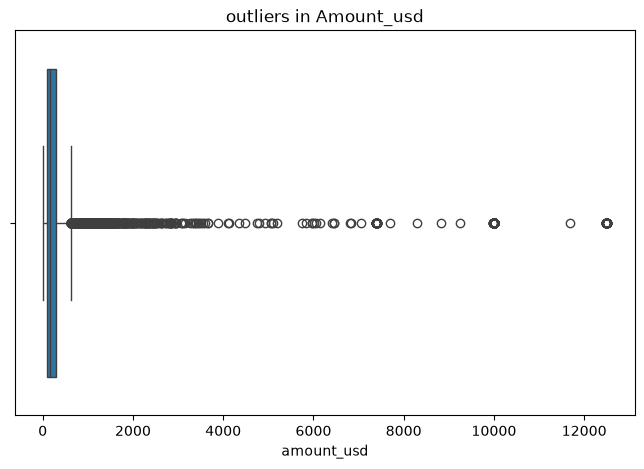

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['amount_usd'])
plt.title('outliers in Amount_usd')
plt.show()

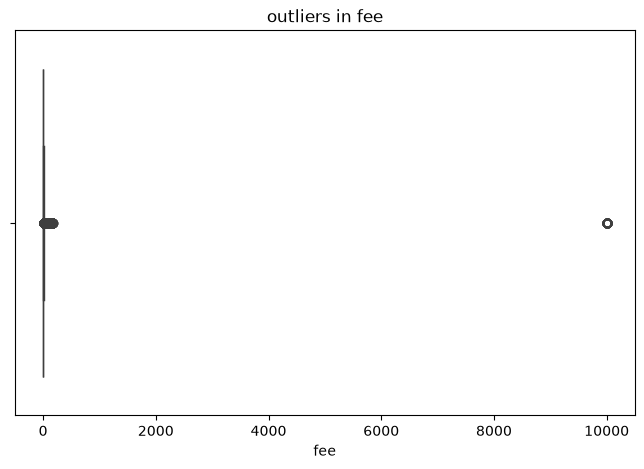

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['fee'])
plt.title('outliers in fee')
plt.show()

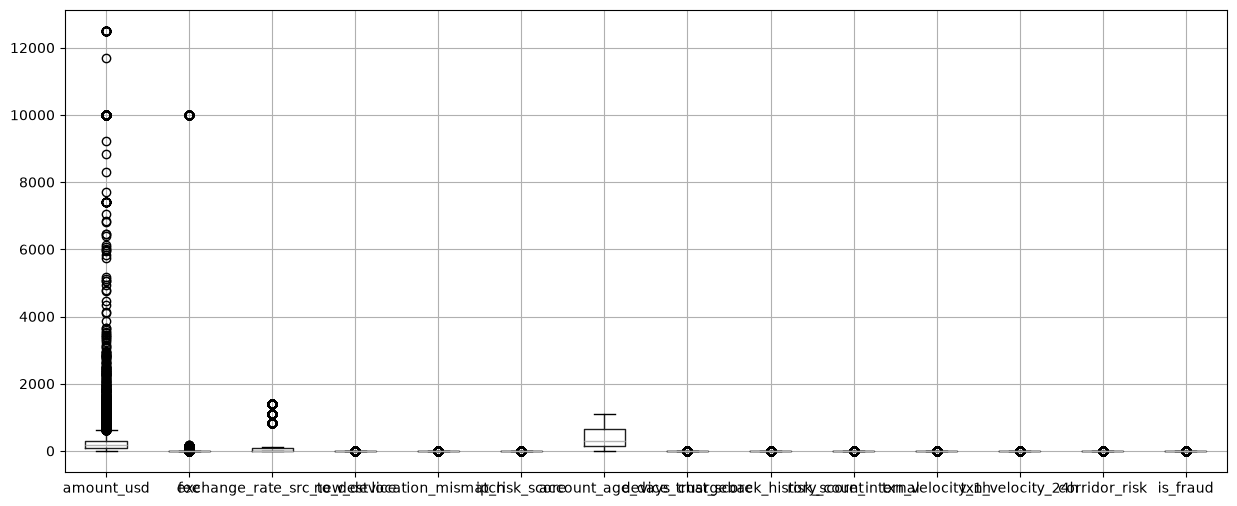

In [41]:
df.boxplot(figsize=(15,6))
plt.show()

In [43]:
# to check for data types 
df.dtypes

transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                       str
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address                       str
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [44]:
# Check for misspellings and inconsistencies
for col in df.select_dtypes(include='object'):
    print(col, df[col].unique())

transaction_id <StringArray>
['fee8542d-8ee6-4b0d-9671-c294dd08ed26',
 'bfdb9fc1-27fe-4a85-b043-4d813d679259',
 'fc855034-3ea5-4993-9afa-b511d93fe5e8',
 '2cf8c08e-42ec-444d-a755-34b9a2a0a4ca',
 'd907a74d-b426-438d-97eb-dbe911aca91c',
 'ec17d6f2-6505-4de9-910f-0de3ac3bbc23',
 '2d8efe37-33ea-40de-9881-e553e3f2f8ce',
 '4d311532-ee0b-4985-b996-63e11a7144d3',
 'db5bdea7-0701-4c07-9efa-815fa6ca9ede',
 'd74c81c0-bf5d-4184-8ce2-27fb753cb1c6',
 ...
 '47f91cf2-d2ed-4770-a0ae-ff35ff25b07b',
 '73883bae-95a5-4484-ad33-81f89e587cf3',
 '0e3f1827-6cfa-484a-bbe6-023c9cf183c1',
 '5cf5c8cb-bd6d-4856-b44f-86a8aed70a91',
 'aa86c811-0a65-421a-b4aa-781a40f5111e',
 'b5ef3323-46d2-4f6c-9c19-43df4e55df48',
 '54f00f78-94aa-4a08-bf6b-12877aa47186',
 '6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5',
 '4aad7389-2b62-4885-a23e-aa3ecd5cfaf9',
 'fdffeb16-192a-4483-9b1e-9928e23269c2']
Length: 11200, dtype: str
customer_id <StringArray>
['402cccc9-28de-45b3-9af7-cc5302aa1f93',
 '67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad',
 '6d0d9b27-f

/var/folders/cp/bfdr0xjj7_j8ky4sx8yck3900000gn/T/ipykernel_60285/3099927785.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):
